# Notebook 08 - Final Summary

Run this last. Pulls all results together into one summary.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec, warnings
warnings.filterwarnings('ignore')
from data_loader import get_monthly_total
from models import make_ml_features, ML_FEATURES
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb

y = get_monthly_total('../data/Tourism_MOM_Dataset.csv')
train = y[y.index < '2025-01-01']
test  = y[y.index >= '2025-01-01']
results   = pd.read_csv('../results/model_results.csv')
forecasts = pd.read_csv('../results/forecasts.csv')
forecasts['Date'] = pd.to_datetime(forecasts['Date'])
wf_summary = pd.read_csv('../results/walkforward_summary.csv')
print("All data loaded.")

All data loaded.


## Complete Results Table

In [2]:
print("="*65)
print("SRI LANKA TOURISM FORECASTING - COMPLETE RESULTS")
print("="*65)
print()
r = results.sort_values('MAPE').reset_index(drop=True)
print("SINGLE HOLDOUT RESULTS (Test: Jan 2025 - Mar 2026):")
for _, row in r.iterrows():
    flag = " <- BEST" if row.name == 0 else ""
    print(f"  {row['Model']:30s}  MAPE={row['MAPE']:6.2f}%  MAE={row['MAE']:9,.0f}{flag}")
print()
print("WALK-FORWARD VALIDATION (Mean MAPE across rolling windows):")
for _, row in wf_summary.iterrows():
    print(f"  {row['Model']:30s}  Mean MAPE={row['Mean MAPE']:6.2f}%  Won {int(row['Best Window Count'])} windows")
print()
best_sh = r.iloc[0]['Model']
best_wf = wf_summary.loc[wf_summary['Mean MAPE'].idxmin(), 'Model']
print("KEY FINDING:")
print(f"  Best model (single holdout): {best_sh} (MAPE {r.iloc[0]['MAPE']}%)")
print(f"  Best model (walk-forward):   {best_wf} (Mean MAPE {wf_summary['Mean MAPE'].min():.2f}%)")

SRI LANKA TOURISM FORECASTING - COMPLETE RESULTS

SINGLE HOLDOUT RESULTS (Test: Jan 2025 - Mar 2026):
  Auto-SARIMA                     MAPE= 12.36%  MAE=   27,109 <- BEST
  Seasonal Naive                  MAPE= 14.19%  MAE=   27,869
  XGBoost                         MAPE= 16.63%  MAE=   31,507
  SARIMA                          MAPE= 22.89%  MAE=   42,083
  SARIMAX                         MAPE= 22.89%  MAE=   42,083
  SARIMA-XGBoost Hybrid           MAPE= 24.43%  MAE=   44,935

WALK-FORWARD VALIDATION (Mean MAPE across rolling windows):
  SARIMA                          Mean MAPE= 25.09%  Won 6 windows
  XGBoost                         Mean MAPE= 27.47%  Won 4 windows
  SARIMA-XGBoost Hybrid           Mean MAPE= 24.05%  Won 6 windows

KEY FINDING:
  Best model (single holdout): Auto-SARIMA (MAPE 12.36%)
  Best model (walk-forward):   SARIMA-XGBoost Hybrid (Mean MAPE 24.05%)


## Master Summary Figure

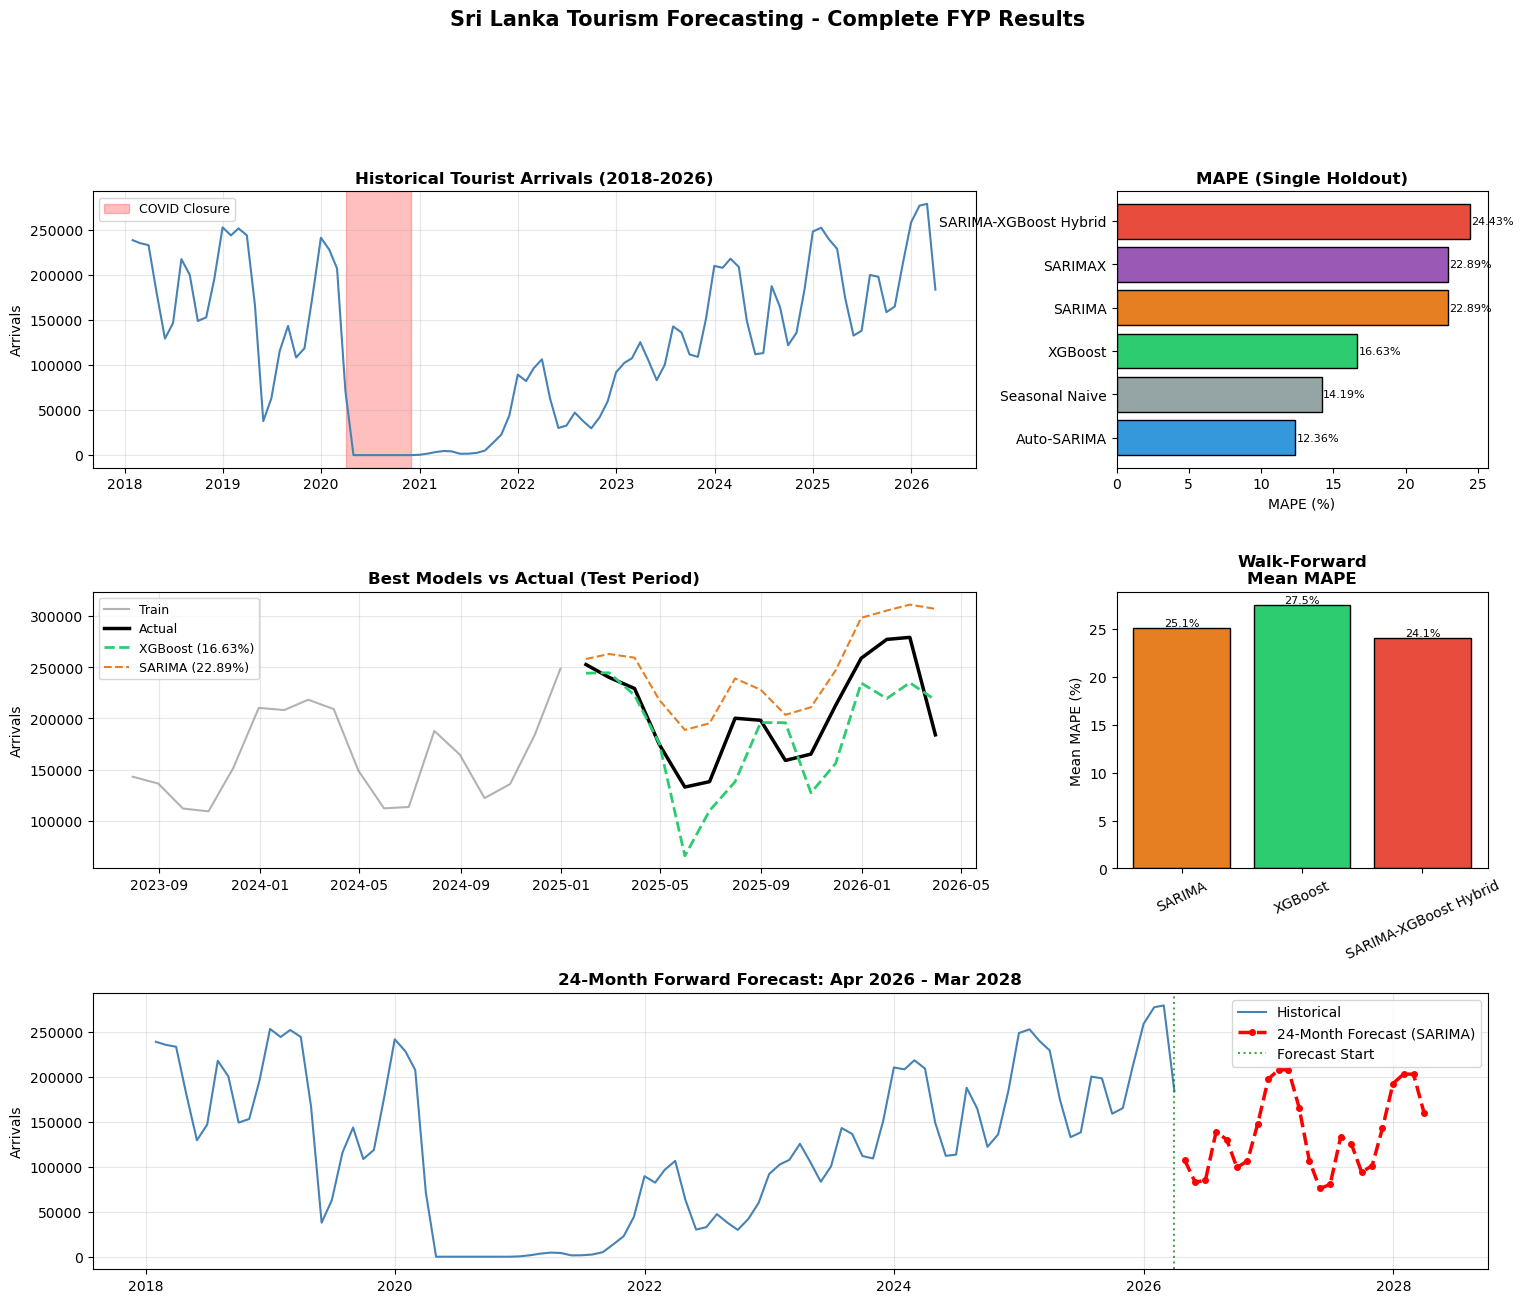

Saved: ../results/08_master_summary.png


In [3]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(y.index, y.values, color='steelblue', linewidth=1.5)
ax1.axvspan(pd.Timestamp('2020-04-01'), pd.Timestamp('2020-11-30'), alpha=0.25, color='red', label='COVID Closure')
ax1.set_title('Historical Tourist Arrivals (2018-2026)', fontweight='bold')
ax1.set_ylabel('Arrivals'); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 2])
colors_map = {'XGBoost':'#2ecc71','Auto-SARIMA':'#3498db','Seasonal Naive':'#95a5a6',
              'SARIMA':'#e67e22','SARIMAX':'#9b59b6','SARIMA-XGBoost Hybrid':'#e74c3c'}
bar_colors = [colors_map.get(m, 'gray') for m in r['Model']]
bars = ax2.barh(r['Model'], r['MAPE'], color=bar_colors, edgecolor='black')
ax2.set_title('MAPE (Single Holdout)', fontweight='bold'); ax2.set_xlabel('MAPE (%)')
for b, v in zip(bars, r['MAPE']):
    ax2.text(v+0.1, b.get_y()+b.get_height()/2, f'{v}%', va='center', fontsize=8)

fd = make_ml_features(y).dropna()
xtr = fd[fd.index < '2025-01-01']; xte = fd[fd.index >= '2025-01-01']
xm = xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
xm.fit(xtr[ML_FEATURES], xtr['y'])
xgb_fc = pd.Series(xm.predict(xte[ML_FEATURES]), index=xte.index)
sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_fc = sarima.forecast(len(test))

ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(train.index[-18:], train.values[-18:], color='gray', alpha=0.6, label='Train')
ax3.plot(test.index, test.values, color='black', linewidth=2.5, label='Actual')
ax3.plot(test.index, xgb_fc.values, '--', color='#2ecc71', linewidth=2, label=f"XGBoost ({r.loc[r['Model']=='XGBoost','MAPE'].iloc[0]}%)")
ax3.plot(test.index, sarima_fc.values, '--', color='#e67e22', linewidth=1.5, label=f"SARIMA ({r.loc[r['Model']=='SARIMA','MAPE'].iloc[0]}%)")
ax3.set_title('Best Models vs Actual (Test Period)', fontweight='bold')
ax3.set_ylabel('Arrivals'); ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 2])
wfc = ['#e67e22','#2ecc71','#e74c3c']
bars2 = ax4.bar(wf_summary['Model'], wf_summary['Mean MAPE'], color=wfc, edgecolor='black')
ax4.set_title('Walk-Forward\nMean MAPE', fontweight='bold')
ax4.set_ylabel('Mean MAPE (%)'); ax4.tick_params(axis='x', rotation=25)
for b, v in zip(bars2, wf_summary['Mean MAPE']):
    ax4.text(b.get_x()+b.get_width()/2, b.get_height()+0.2, f'{v:.1f}%', ha='center', fontsize=8)

ax5 = fig.add_subplot(gs[2, :])
ax5.plot(y.index, y.values, color='steelblue', label='Historical', linewidth=1.5)
ax5.plot(forecasts['Date'], forecasts['Forecast'], color='red', linewidth=2.5,
         marker='o', markersize=4, linestyle='--', label='24-Month Forecast (SARIMA)')
ax5.axvline(x=y.index[-1], color='green', linestyle=':', alpha=0.7, label='Forecast Start')
ax5.set_title('24-Month Forward Forecast: Apr 2026 - Mar 2028', fontweight='bold')
ax5.set_ylabel('Arrivals'); ax5.legend(fontsize=10); ax5.grid(alpha=0.3)

fig.suptitle('Sri Lanka Tourism Forecasting - Complete FYP Results', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('../results/08_master_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/08_master_summary.png")

## All Generated Files

In [4]:
import os
print("NOTEBOOKS:")
for f in sorted(os.listdir('../notebooks')):
    if f.endswith('.ipynb'):
        print(f"  {f}  ({os.path.getsize(f'../notebooks/{f}')//1024} KB)")
print("\nRESULTS:")
for f in sorted(os.listdir('../results')):
    print(f"  {f}  ({os.path.getsize(f'../results/{f}')//1024} KB)")
print("\nIMPLEMENTATION 100% COMPLETE.")

NOTEBOOKS:
  00_data_preprocessing.ipynb  (354 KB)
  01_data_exploration.ipynb  (147 KB)
  02_baseline_models.ipynb  (106 KB)
  03_sarima_models.ipynb  (110 KB)
  04_xgboost_model.ipynb  (127 KB)
  05_hybrid_sarima_xgboost.ipynb  (188 KB)
  06_walkforward_validation.ipynb  (148 KB)
  07_residual_analysis.ipynb  (304 KB)
  08_final_summary.ipynb  (322 KB)
  09_hyperparameter_tuning.ipynb  (66 KB)
  10_diagnostics_and_improvements.ipynb  (262 KB)
  11_hybrid_tuning.ipynb  (50 KB)
  12_covid_handling_and_final_tuning.ipynb  (204 KB)

RESULTS:
  00_decomposition.png  (283 KB)
  00_train_test_split.png  (109 KB)
  01_historical.png  (123 KB)
  01_seasonality.png  (42 KB)
  02_seasonal_naive.png  (121 KB)
  03_sarima.png  (125 KB)
  04_xgb_importance.png  (29 KB)
  04_xgboost.png  (109 KB)
  05_comparison.png  (68 KB)
  06_future_forecast.png  (143 KB)
  06_walkforward.png  (156 KB)
  07_residual_acf.png  (46 KB)
  07_residual_analysis.png  (143 KB)
  07_sarima_fit.png  (169 KB)
  08_master_